In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [19]:

from google.colab import files
uploaded = files.upload()
column_names = [f'feature_{i}' for i in range(57)] + ['spam']
df = pd.read_csv('spambase.data', names=column_names)
print( df.shape)
df.head()

Saving spambase.data to spambase (2).data
(4601, 58)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


Data Summary:

Class distribution (0 = not spam | 1 = spam):
spam
0    2788
1    1813
Name: count, dtype: int64


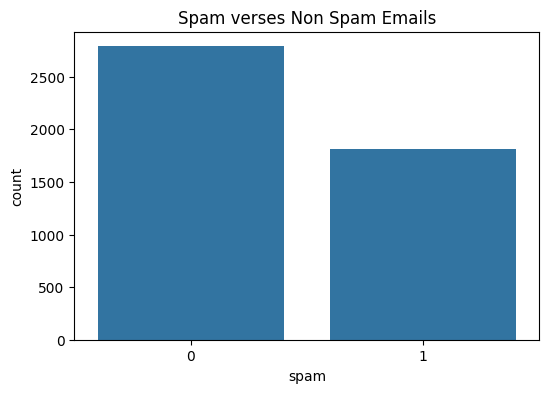

In [23]:

data_summary = df.describe()
print("Data Summary:")
data_summary


print("\nClass distribution (0 = not spam | 1 = spam):")
print(df['spam'].value_counts())


plt.figure(figsize=(6,4))
sns.countplot(x='spam', data=df)
plt.title('Spam verses Non Spam Emails')
plt.show()

In [6]:
X = df.drop('spam', axis=1)
y = df['spam']



In [8]:
def run_naive_bayes(X, y, test_size, random_state=42):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    nb = GaussianNB()
    nb.fit(X_train_scaled, y_train)


    y_pred = nb.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)


    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return {
        'confusion_matrix': cm,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'specificity': spec,
        'f1_score': f1,
        'y_test': y_test,
        'y_pred': y_pred
    }

In [9]:
results_80_20 = run_naive_bayes(X, y, test_size=0.20)
results_60_40 = run_naive_bayes(X, y, test_size=0.40)

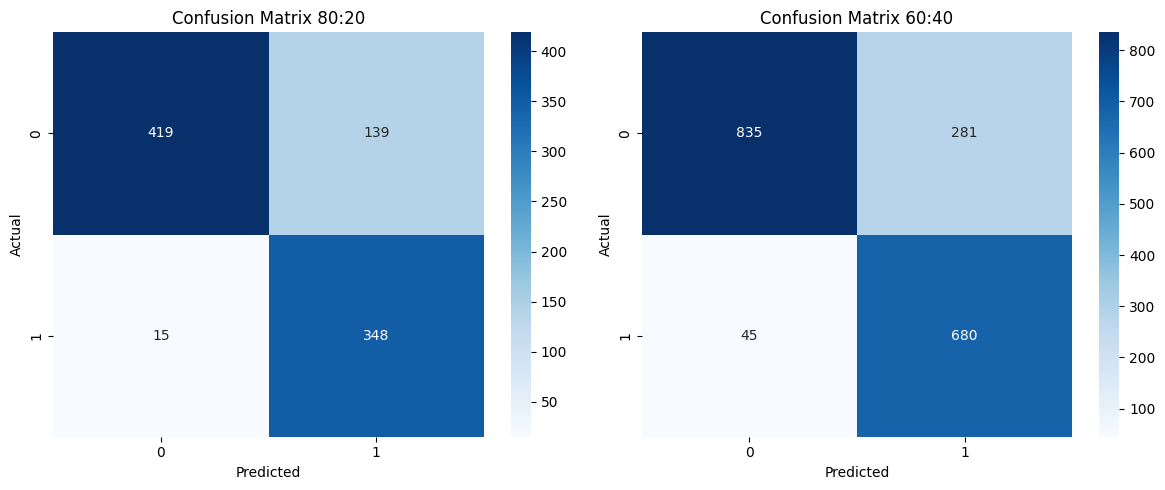

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.heatmap(results_80_20['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix 80:20')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(results_60_40['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix 60:40')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [25]:
report = {
    'Metric': ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity', 'F1-Score'],
    '80:20': [
        results_80_20['accuracy'],
        results_80_20['precision'],
        results_80_20['recall'],
        results_80_20['specificity'],
        results_80_20['f1_score']
    ],
    '60:40': [
        results_60_40['accuracy'],
        results_60_40['precision'],
        results_60_40['recall'],
        results_60_40['specificity'],
        results_60_40['f1_score']
    ]
}

performance_df = pd.DataFrame(report)
performance_df.round(4)

,Metric,80:20,60:40
0,Accuracy,0.8328,0.8229
1,Precision,0.7146,0.7076
2,Recall (Sensitivity),0.9587,0.9379
3,Specificity,0.7509,0.7482
4,F1-Score,0.8188,0.8066


In [26]:
report = {
    'Metric': ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity', 'F1-Score'],
    '80:20': [
        results_80_20['accuracy'],
        results_80_20['precision'],
        results_80_20['recall'],
        results_80_20['specificity'],
        results_80_20['f1_score']
    ],
    '60:40': [
        results_60_40['accuracy'],
        results_60_40['precision'],
        results_60_40['recall'],
        results_60_40['specificity'],
        results_60_40['f1_score']
    ]
}

performance_df = pd.DataFrame(report)
performance_df.round(4)

,Metric,80:20,60:40
0,Accuracy,0.8328,0.8229
1,Precision,0.7146,0.7076
2,Recall (Sensitivity),0.9587,0.9379
3,Specificity,0.7509,0.7482
4,F1-Score,0.8188,0.8066


In [29]:


column_names = [f'feature_{i}' for i in range(57)] + ['spam']
df = pd.read_csv('spambase.data', names=column_names)
print("Original shape:", df.shape)
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)
missing = df.isnull().sum().sum()
print("Missing values=", missing)
df_clean = df.drop_duplicates()
df_clean = df_clean.replace([float('inf'), -float('inf')], pd.NA).dropna()
print("Cleaned shape=", df_clean.shape)

Original shape: (4601, 58)
Duplicate rows: 391
Missing values= 0
Cleaned shape= (4210, 58)
